# Scresh — DINOv3 Segmentation + Freshness Training Full Pipeline

Notebook ini menjalankan pipeline Scresh end-to-end:

```text
Raw produce image
→ manual DINOv3 preprocessing
→ DINOv3 frozen ViT encoder
→ lightweight binary segmentation decoder
→ produce mask
→ multi-component object extraction
→ crop each object
→ EfficientNet-B0 freshness classifier
→ Grade A/B/C/D + shelf-life
```

Versi ini dibuat untuk:
- Tetap pakai **DINOv3**
- Tidak pakai EoMT / Mask2Former
- Tidak pakai `AutoImageProcessor`
- Tidak import `torchvision`
- Preprocessing DINOv3 ditulis manual
- Segmentasi bisa mengambil **banyak objek terpisah** lewat connected components
- Tambah training freshness classifier dari dataset image folder
- Output Scresh JSON sudah bisa berisi banyak object per image

## 0. Recommended Kaggle/Colab setup

Di Kaggle:
1. Enable GPU.
2. Add dataset segmentation yang punya format YOLO polygon.
3. Jangan aktifkan fruits segmentation dataset kecuali label polygon-nya beneran detail.
4. Kalau DINOv3 model gated, tambahkan secret `HF_TOKEN` di Kaggle/Colab.
5. Run CELL 1 sebagai dependency check saja. Jangan update dependency kecuali memang error.

Notebook ini sengaja tidak install `transformers` dari GitHub source dan tidak mengubah `torch/torchvision`.

In [1]:
# =========================
# CELL 1 — SAFE DEPENDENCY CHECK
# =========================
# Default: JANGAN update/install apa pun.
# Ini sengaja dibuat aman supaya Kaggle/Colab environment tidak rusak karena dependency upgrade.
#
# Kalau ada package yang belum ada / versi kurang, baru ubah INSTALL_DEPS = True.
# Kalau error PIL._typing/_Ink, baru ubah FIX_PILLOW_ONLY = True, run cell ini, lalu restart kernel.

import sys
import subprocess
import importlib
import importlib.metadata as metadata

INSTALL_DEPS = False
FIX_PILLOW_ONLY = False

REQUIRED = {
    "transformers": "4.57.0",
    "huggingface_hub": None,
    "accelerate": None,
    "safetensors": None,
    "timm": None,
    "opencv-python-headless": None,
    "matplotlib": None,
    "pillow": None,
    "tqdm": None,
    "scikit-learn": None,
    "requests": None,
}

def get_version(pkg_name):
    try:
        return metadata.version(pkg_name)
    except metadata.PackageNotFoundError:
        return None

print("Current package versions:")
for pkg, min_ver in REQUIRED.items():
    v = get_version(pkg)
    print(f"{pkg:<24} {v}")

if FIX_PILLOW_ONLY:
    print("\nFixing Pillow only...")
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "-q", "--upgrade", "--force-reinstall", "--no-cache-dir",
        "pillow>=11.3.0"
    ])
    print("Pillow fixed. Restart kernel/session before continuing.")

if INSTALL_DEPS:
    print("\nInstalling/upgrading only minimal non-torch dependencies...")
    packages = [
        "transformers>=4.57.0",
        "huggingface_hub",
        "accelerate",
        "safetensors",
        "timm",
        "opencv-python-headless",
        "matplotlib",
        "pillow>=11.3.0",
        "tqdm",
        "scikit-learn",
        "requests",
    ]

    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "-q", "--upgrade",
        *packages
    ])
    print("Install done. Restart kernel/session once if anything was upgraded.")
else:
    print("\nNo install/update performed. Good. Continue to CELL 2.")

Current package versions:
transformers             5.0.0
huggingface_hub          1.10.1
accelerate               1.13.0
safetensors              0.7.0
timm                     1.0.26
opencv-python-headless   4.13.0.92
matplotlib               3.10.0
pillow                   11.3.0
tqdm                     4.67.3
scikit-learn             1.6.1
requests                 2.32.4

No install/update performed. Good. Continue to CELL 2.


In [2]:
# =========================
# CELL 2 — IMPORTS
# =========================

import os
import json
import math
import random
import shutil
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

# Important:
# We intentionally import AutoModel only.
# We do NOT import AutoImageProcessor because it can trigger torchvision/Pillow errors.
from transformers import AutoModel
from huggingface_hub import login, whoami

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

img_test = Image.new("RGB", (8, 8), color=(255, 0, 0))
print("PIL sanity check:", img_test.size)

torch: 2.10.0+cu128
cuda available: True
device: cuda
PIL sanity check: (8, 8)


In [3]:
# =========================
# CELL 3 — CONFIG
# =========================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# DINOv3 backbone.
DINO_MODEL_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"

# DINOv3 official Meta checkpoint is gated.
# Since you already got access:
# 1. Create Hugging Face READ token.
# 2. Kaggle > Add-ons > Secrets > add secret named HF_TOKEN.
# 3. Rerun from this cell.
HF_TOKEN = os.environ.get("HF_TOKEN", None)
REQUIRE_HF_TOKEN = True

# Segmentation input size should be divisible by ViT patch size 16.
IMG_SIZE = 512

# Segmentation training config.
EPOCHS = 8
BATCH_SIZE = 2
LR = 2e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 2
FREEZE_DINO = True
USE_AMP = True

# Label quality filter.
DROP_BOXY_SEG_LABELS = True
MIN_SEG_POLYGON_POINTS = 6
MIN_MASK_AREA_RATIO = 0.005
MAX_MASK_AREA_RATIO = 0.98

# Multi-object segmentation extraction.
# DINOv3 decoder here is binary semantic segmentation, not instance segmentation.
# Banyak objek bisa diekstrak kalau terpisah sebagai connected components.
SEG_MULTI_OBJECT = True
SEG_KEEP_LARGEST_ONLY = False
SEG_MIN_COMPONENT_AREA = 250
SEG_MAX_OBJECTS = 10
SEG_COMPONENT_PAD = 8
SEG_MASK_THRESHOLD = 0.50

# Freshness training config.
TRAIN_FRESHNESS = True
FRESH_IMG_SIZE = 224
FRESH_EPOCHS = 8
FRESH_BATCH_SIZE = 16
FRESH_LR = 2e-4
FRESH_WEIGHT_DECAY = 1e-4
FRESH_MODEL_NAME = "efficientnet_b0"

# Save paths.
WORK_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path("./scresh_working")
WORK_DIR.mkdir(parents=True, exist_ok=True)

SEG_MODEL_SAVE_PATH = WORK_DIR / "scresh_dinov3_frozen_decoder_best.pt"
SEG_METADATA_PATH = WORK_DIR / "scresh_dinov3_frozen_decoder_metadata.json"

FRESH_MODEL_SAVE_PATH = WORK_DIR / "scresh_freshness_efficientnet_b0_best.pt"
FRESH_METADATA_PATH = WORK_DIR / "scresh_freshness_metadata.json"

print("WORK_DIR:", WORK_DIR)
print("Segmentation model:", SEG_MODEL_SAVE_PATH)
print("Freshness model:", FRESH_MODEL_SAVE_PATH)

WORK_DIR: /kaggle/working
Segmentation model: /kaggle/working/scresh_dinov3_frozen_decoder_best.pt
Freshness model: /kaggle/working/scresh_freshness_efficientnet_b0_best.pt


In [4]:
# =========================
# CELL 4 — DATASET SOURCES + AUTO DISCOVERY
# =========================
# Error "raw image-label pairs: 0" biasanya karena path dataset beda dari asumsi.
# Cell ini auto-scan /kaggle/input supaya kita lihat dataset apa saja yang kebaca.

KAGGLE_INPUT = Path("/kaggle/input")

AUTO_SCAN_KAGGLE_INPUT = True

# Set True hanya kalau lu memang mau fruits ikut segmentation.
# Default False karena fruits segmentation sebelumnya dicurigai boxy.
ALLOW_FRUITS_SEGMENTATION = False

MANUAL_SEG_ROOTS = [
    "/kaggle/input/lettuce-yolodataset",
    "/kaggle/input/lettuce-health-level-detection",
    "/kaggle/input/chili-segmentation",
    "/kaggle/input/tomato-segmentation",
    "/kaggle/input/onion-segmentation",
    "/kaggle/input/fruits/Fruits-Segmentation.yolov8",
]

def show_tree(root, max_depth=2, max_items=80):
    root = Path(root)
    if not root.exists():
        print("Not found:", root)
        return

    print(f"\nTree: {root}")
    count = 0
    root_depth = len(root.parts)

    for p in sorted(root.rglob("*")):
        depth = len(p.parts) - root_depth
        if depth > max_depth:
            continue

        indent = "  " * max(0, depth - 1)
        print(f"{indent}- {p.name}{'/' if p.is_dir() else ''}")
        count += 1

        if count >= max_items:
            print("  ... truncated ...")
            break

if KAGGLE_INPUT.exists():
    print("Top-level /kaggle/input datasets:")
    for p in sorted(KAGGLE_INPUT.iterdir()):
        if p.is_dir():
            print(" -", p.name)
else:
    print("/kaggle/input not found. If running local, update MANUAL_SEG_ROOTS.")

# Show shallow tree for debugging.
if KAGGLE_INPUT.exists():
    show_tree(KAGGLE_INPUT, max_depth=2, max_items=120)

SEG_SOURCES = []

# Manual roots first.
for root in MANUAL_SEG_ROOTS:
    p = Path(root)
    if not p.exists():
        continue

    name = p.name.lower()
    is_fruits = "fruit" in str(p).lower()
    enabled = (not is_fruits) or ALLOW_FRUITS_SEGMENTATION

    SEG_SOURCES.append({
        "name": p.name,
        "path": str(p),
        "enabled": enabled,
    })

# Auto scan all Kaggle input dirs.
if AUTO_SCAN_KAGGLE_INPUT and KAGGLE_INPUT.exists():
    for p in sorted(KAGGLE_INPUT.iterdir()):
        if not p.is_dir():
            continue

        name = p.name.lower()
        is_fruits = "fruit" in name
        enabled = (not is_fruits) or ALLOW_FRUITS_SEGMENTATION

        SEG_SOURCES.append({
            "name": p.name,
            "path": str(p),
            "enabled": enabled,
        })

# Deduplicate by path.
seen = set()
unique_sources = []
for src in SEG_SOURCES:
    if src["path"] not in seen:
        seen.add(src["path"])
        unique_sources.append(src)
SEG_SOURCES = unique_sources

print("\nSEG_SOURCES:")
for src in SEG_SOURCES:
    p = Path(src["path"])
    print(f"{src['name']:<40} enabled={src['enabled']} exists={p.exists()} path={p}")

if len(SEG_SOURCES) == 0:
    print("\nNo SEG_SOURCES found. Add your dataset path manually in MANUAL_SEG_ROOTS.")

Top-level /kaggle/input datasets:
 - datasets

Tree: /kaggle/input
- datasets/
  - athillazaidan/
  - sujaykapadnis/

SEG_SOURCES:
datasets                                 enabled=True exists=True path=/kaggle/input/datasets


In [5]:
# =========================
# CELL 5 — ROBUST YOLO SEG DATASET DISCOVERY
# =========================

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def is_probably_yolo_label(label_path: Path) -> bool:
    if label_path.suffix.lower() != ".txt":
        return False

    try:
        text = label_path.read_text(errors="ignore").strip()
    except Exception:
        return False

    if not text:
        return False

    # Skip common non-label txt files.
    bad_names = {"readme.txt", "classes.txt", "notes.txt", "license.txt"}
    if label_path.name.lower() in bad_names:
        return False

    first = text.splitlines()[0].strip().split()
    if len(first) < 5:
        return False

    try:
        [float(x) for x in first]
        return True
    except Exception:
        return False


def index_images_by_stem(root: Path):
    image_files = [p for p in root.rglob("*") if p.suffix.lower() in IMG_EXTS]
    by_stem = {}

    for img in image_files:
        by_stem.setdefault(img.stem, []).append(img)

    return image_files, by_stem


def score_image_label_match(img: Path, label: Path) -> int:
    # Higher is better.
    img_parts = [x.lower() for x in img.parts]
    label_parts = [x.lower() for x in label.parts]
    score = 0

    if img.stem == label.stem:
        score += 100

    if "images" in img_parts and "labels" in label_parts:
        score += 20

    # Prefer same split train/valid/test if present.
    for split in ["train", "valid", "val", "test"]:
        if split in img_parts and split in label_parts:
            score += 10

    # Prefer closer paths.
    common = len(set(img_parts) & set(label_parts))
    score += common

    return score


def find_yolo_image_label_pairs(root: str) -> List[Dict]:
    root = Path(root)
    if not root.exists():
        return []

    image_files, images_by_stem = index_images_by_stem(root)
    label_files = [p for p in root.rglob("*.txt") if is_probably_yolo_label(p)]

    print(f"Scanning {root.name}: images={len(image_files)} label_txt={len(label_files)}")

    pairs = []
    for label_path in label_files:
        candidates = []

        # 1. Same stem global search.
        candidates.extend(images_by_stem.get(label_path.stem, []))

        # 2. Common YOLO labels->images replacement.
        parts = list(label_path.parts)
        if "labels" in parts:
            idx = parts.index("labels")
            img_parts = parts.copy()
            img_parts[idx] = "images"
            base = Path(*img_parts).with_suffix("")
            for ext in IMG_EXTS:
                c = base.with_suffix(ext)
                if c.exists():
                    candidates.append(c)

        # 3. Same folder fallback.
        for ext in IMG_EXTS:
            c = label_path.with_suffix(ext)
            if c.exists():
                candidates.append(c)

        # Dedup candidates.
        candidates = list(dict.fromkeys(candidates))

        if not candidates:
            continue

        best_img = sorted(
            candidates,
            key=lambda img: score_image_label_match(img, label_path),
            reverse=True,
        )[0]

        pairs.append({
            "image_path": str(best_img),
            "label_path": str(label_path),
            "source_root": str(root),
        })

    # Deduplicate.
    seen = set()
    unique = []
    for item in pairs:
        key = (item["image_path"], item["label_path"])
        if key not in seen:
            seen.add(key)
            unique.append(item)

    return unique


def yolo_line_to_polygon(line: str, w: int, h: int, min_points: int = 6) -> Optional[np.ndarray]:
    # YOLO segmentation line:
    # class x1 y1 x2 y2 ... xn yn
    # normalized coords.
    parts = line.strip().split()
    if len(parts) < 7:
        return None

    coords = parts[1:]

    # Detection bbox line has 4 coords only.
    if len(coords) == 4:
        return None

    if len(coords) % 2 != 0:
        return None

    point_count = len(coords) // 2
    if DROP_BOXY_SEG_LABELS and point_count < min_points:
        return None

    try:
        vals = np.array([float(x) for x in coords], dtype=np.float32).reshape(-1, 2)
    except Exception:
        return None

    vals[:, 0] = np.clip(vals[:, 0] * w, 0, w - 1)
    vals[:, 1] = np.clip(vals[:, 1] * h, 0, h - 1)

    poly = vals.astype(np.int32)
    return poly


def build_binary_mask_from_yolo(label_path: str, image_size_wh: Tuple[int, int]) -> np.ndarray:
    # Build one-class produce binary mask from all polygons in YOLO label file.
    w, h = image_size_wh
    mask = np.zeros((h, w), dtype=np.uint8)

    label_path = Path(label_path)
    if not label_path.exists():
        return mask

    lines = label_path.read_text(errors="ignore").strip().splitlines()
    for line in lines:
        poly = yolo_line_to_polygon(line, w=w, h=h, min_points=MIN_SEG_POLYGON_POINTS)
        if poly is None or len(poly) < 3:
            continue
        cv2.fillPoly(mask, [poly], 1)

    return mask


def valid_mask(mask: np.ndarray) -> bool:
    area_ratio = float(mask.sum()) / float(mask.shape[0] * mask.shape[1])
    return MIN_MASK_AREA_RATIO <= area_ratio <= MAX_MASK_AREA_RATIO


all_pairs = []
for src in SEG_SOURCES:
    if not src["enabled"]:
        continue
    pairs = find_yolo_image_label_pairs(src["path"])
    for p in pairs:
        p["source_name"] = src["name"]
    all_pairs.extend(pairs)

print("\nraw image-label pairs:", len(all_pairs))

# Filter pairs with valid masks.
valid_pairs = []
bad_pairs = []
boxy_or_detection_like = 0
empty_masks = 0

for item in tqdm(all_pairs, desc="checking masks"):
    try:
        img = Image.open(item["image_path"]).convert("RGB")
        w, h = img.size
        mask = build_binary_mask_from_yolo(item["label_path"], (w, h))

        if valid_mask(mask):
            valid_pairs.append(item)
        else:
            bad_pairs.append(item)
            if mask.sum() == 0:
                empty_masks += 1
    except Exception as e:
        item["error"] = str(e)
        bad_pairs.append(item)

print("valid pairs:", len(valid_pairs))
print("bad/boxy/empty skipped:", len(bad_pairs))
print("empty masks:", empty_masks)

if len(all_pairs) > 0:
    print("\nExample raw pairs:")
    for x in all_pairs[:5]:
        print("IMG :", x["image_path"])
        print("LAB :", x["label_path"])
        print("---")

if len(valid_pairs) == 0:
    print("\nNo valid segmentation masks found.")
    print("Possible causes:")
    print("1. Dataset path exists but is detection bbox format, not segmentation polygon.")
    print("2. Labels are boxy/4-point polygons and DROP_BOXY_SEG_LABELS=True filtered them.")
    print("3. Your dataset is not YOLO format.")
    print("4. The enabled source is not the dataset you intended.")
    print("\nDebug tips:")
    print("- Check CELL 4 tree output.")
    print("- Temporarily set DROP_BOXY_SEG_LABELS=False to see if labels are just boxy.")
    print("- Open a label .txt. Segmentation line should have many coords, not only class x y w h.")
    print("- If using Roboflow, export as YOLOv8 Segmentation, not YOLOv8 Detection.")

assert len(valid_pairs) > 0, "No valid segmentation pairs found. Check SEG_SOURCES and label format."

Scanning datasets: images=16234 label_txt=3247

raw image-label pairs: 3247


checking masks:   0%|          | 0/3247 [00:00<?, ?it/s]

valid pairs: 1598
bad/boxy/empty skipped: 1649
empty masks: 1649

Example raw pairs:
IMG : /kaggle/input/datasets/athillazaidan/kentang-freshness/Rotten and Healthy Potatoes.yolov8/valid/images/rotten (196)_jpg.rf.ocKGSOtnGHiHfSDGxWY5.jpg
LAB : /kaggle/input/datasets/athillazaidan/kentang-freshness/Rotten and Healthy Potatoes.yolov8/valid/labels/rotten (196)_jpg.rf.ocKGSOtnGHiHfSDGxWY5.txt
---
IMG : /kaggle/input/datasets/athillazaidan/kentang-freshness/Rotten and Healthy Potatoes.yolov8/valid/images/Healthy Potato Aug (477)_jpg.rf.RP2hFOnwXLvev9H9rB0A.jpg
LAB : /kaggle/input/datasets/athillazaidan/kentang-freshness/Rotten and Healthy Potatoes.yolov8/valid/labels/Healthy Potato Aug (477)_jpg.rf.RP2hFOnwXLvev9H9rB0A.txt
---
IMG : /kaggle/input/datasets/athillazaidan/kentang-freshness/Rotten and Healthy Potatoes.yolov8/valid/images/Healthy Potato Aug (155)_jpg.rf.hiSp34e64qlf0pzvN85P.jpg
LAB : /kaggle/input/datasets/athillazaidan/kentang-freshness/Rotten and Healthy Potatoes.yolov8/valid

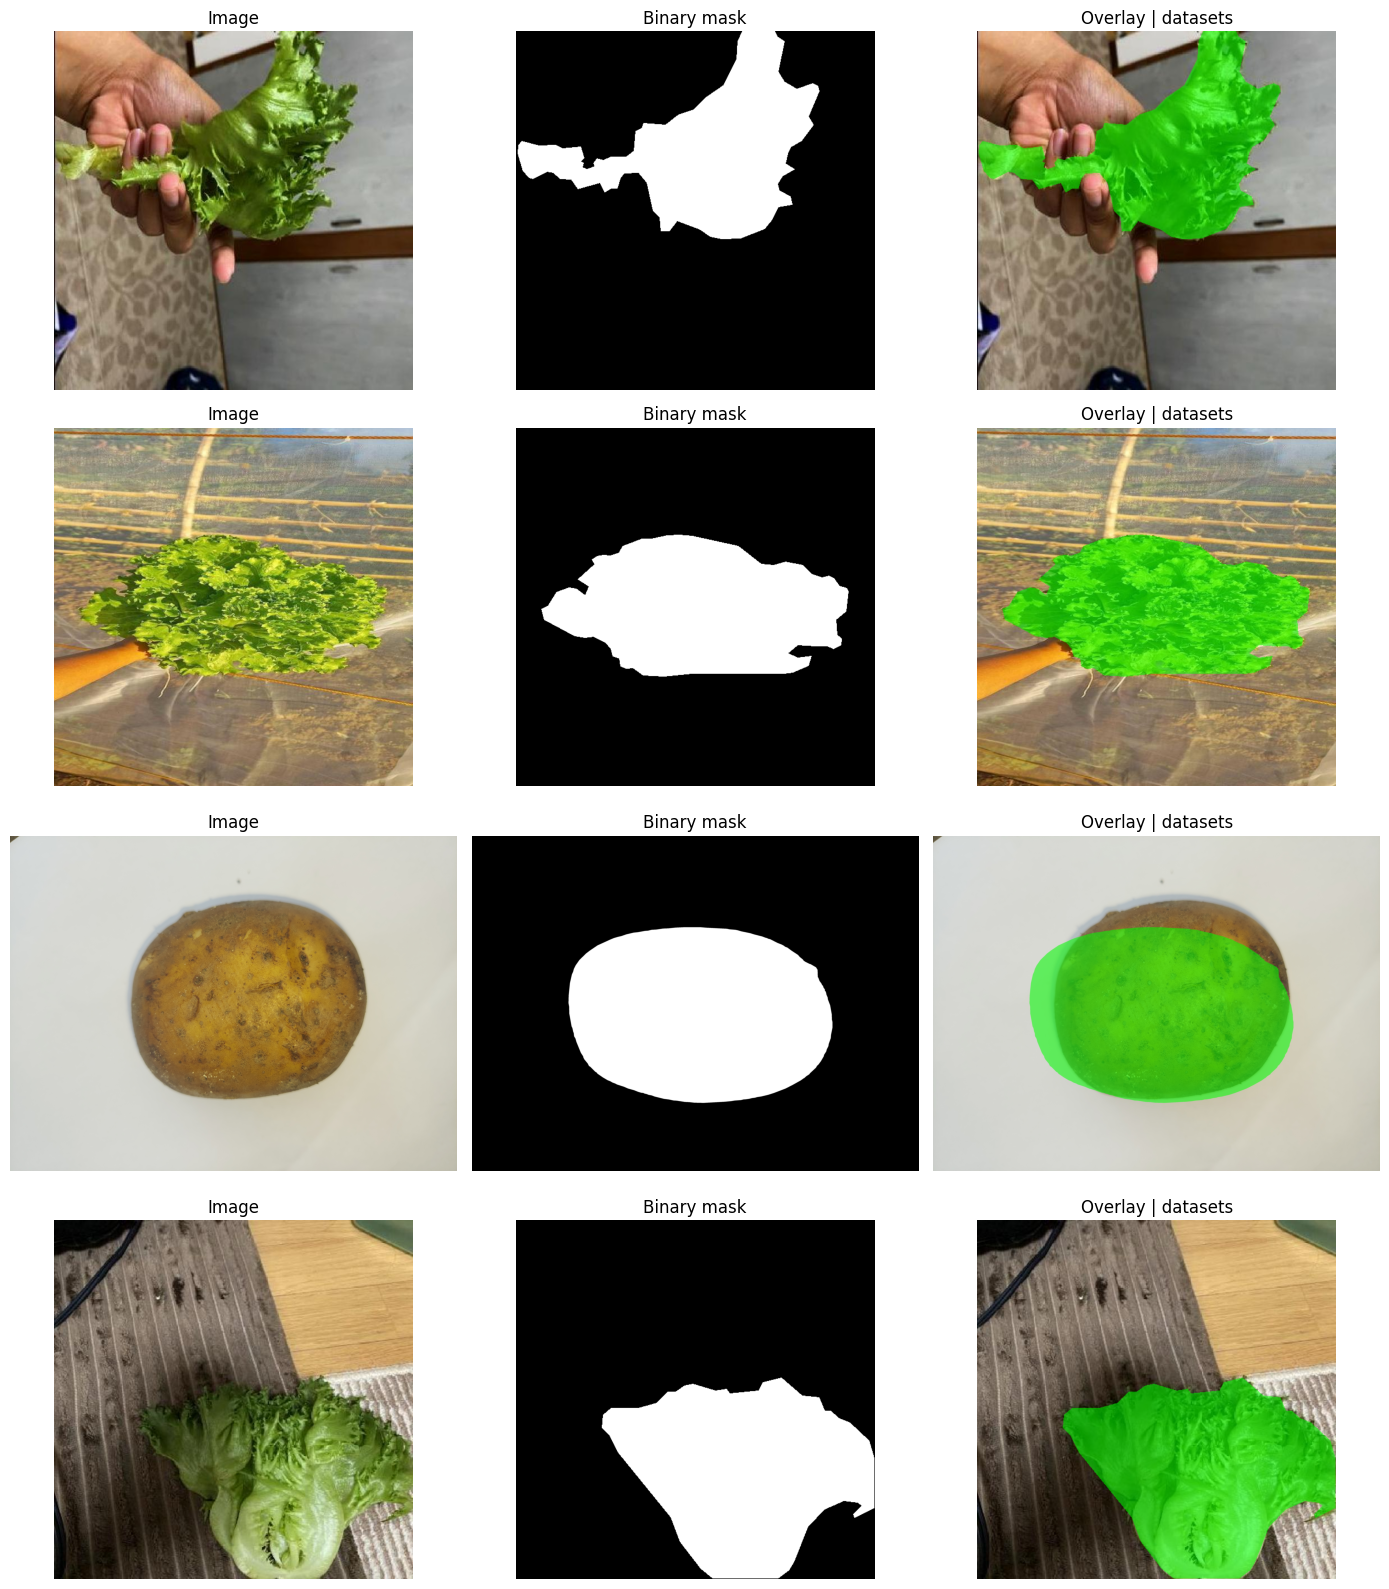

In [6]:
# =========================
# CELL 6 — VISUALIZE DATASET MASKS
# =========================

def overlay_mask(image_rgb: np.ndarray, mask: np.ndarray, alpha: float = 0.55) -> np.ndarray:
    image = image_rgb.copy()
    color = np.zeros_like(image)
    color[..., 1] = 255
    mask_bool = mask.astype(bool)

    out = image.copy()
    out[mask_bool] = (image[mask_bool] * (1 - alpha) + color[mask_bool] * alpha).astype(np.uint8)
    return out


def show_random_dataset_samples(pairs, n=4):
    n = min(n, len(pairs))
    sample = random.sample(pairs, n)

    plt.figure(figsize=(14, 4 * n))
    for i, item in enumerate(sample):
        img = Image.open(item["image_path"]).convert("RGB")
        img_np = np.array(img)
        w, h = img.size
        mask = build_binary_mask_from_yolo(item["label_path"], (w, h))
        overlay = overlay_mask(img_np, mask)

        plt.subplot(n, 3, i * 3 + 1)
        plt.imshow(img_np)
        plt.title("Image")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 2)
        plt.imshow(mask, cmap="gray")
        plt.title("Binary mask")
        plt.axis("off")

        plt.subplot(n, 3, i * 3 + 3)
        plt.imshow(overlay)
        plt.title(f"Overlay | {item['source_name']}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_dataset_samples(valid_pairs, n=4)

In [7]:
# =========================
# OPTIONAL — HF TOKEN SANITY CHECK
# =========================
# Run this if DINOv3 loading still fails.
# It checks whether Kaggle Secrets can read HF_TOKEN and which HF user is logged in.

RUN_HF_DEBUG = False

if RUN_HF_DEBUG:
    from kaggle_secrets import UserSecretsClient

    user_secrets = UserSecretsClient()
    token_debug = user_secrets.get_secret("HF_TOKEN")

    print("Token loaded:", token_debug is not None)
    print("Token prefix:", token_debug[:6] if token_debug else None)
    print("Token length:", len(token_debug) if token_debug else None)

    login(token=token_debug, add_to_git_credential=False)
    info = whoami(token=token_debug)
    print("Logged in as:", info["name"])

    test_model = AutoModel.from_pretrained(
        DINO_MODEL_ID,
        token=token_debug,
    )
    print("DINOv3 loaded successfully for debug.")
    del test_model
    if device == "cuda":
        torch.cuda.empty_cache()
else:
    print("RUN_HF_DEBUG=False. Skip debug.")

RUN_HF_DEBUG=False. Skip debug.


In [9]:
# =========================
# CELL 7 — LOAD DINOv3 BACKBONE
# =========================
# Minimal import setup:
# - uses AutoModel only
# - does NOT use AutoImageProcessor
# - does NOT import torchvision
#
# DINOv3 is gated, so this cell loads HF_TOKEN from:
# 1. os.environ["HF_TOKEN"], or
# 2. Kaggle Secrets named HF_TOKEN

def load_hf_token():
    token = globals().get("HF_TOKEN", None) or os.environ.get("HF_TOKEN", None)

    if token:
        return token

    try:
        from kaggle_secrets import UserSecretsClient
        user_secrets = UserSecretsClient()
        token = user_secrets.get_secret("HF_TOKEN")
        if token:
            return token
    except Exception:
        pass

    return None

HF_TOKEN = load_hf_token()

if REQUIRE_HF_TOKEN and not HF_TOKEN:
    raise RuntimeError(
        "\nHF_TOKEN not found. DINOv3 is gated.\n"
        "Kaggle fix:\n"
        "1. Hugging Face > Settings > Access Tokens > create READ token.\n"
        "2. Kaggle Notebook > Add-ons > Secrets > add secret.\n"
        "3. Name: HF_TOKEN\n"
        "4. Value: hf_xxxxxxxxx\n"
        "5. Rerun from CELL 3.\n"
    )

if HF_TOKEN:
    print("HF_TOKEN found. Logging in...")
    login(token=HF_TOKEN, add_to_git_credential=False)
else:
    print("No HF_TOKEN found. Trying anonymous load, may fail for gated DINOv3.")

print("Loading backbone:", DINO_MODEL_ID)

try:
    dino_backbone = AutoModel.from_pretrained(
        DINO_MODEL_ID,
        token=HF_TOKEN if HF_TOKEN else None,
    )
except Exception as e:
    msg = str(e).lower()
    if "gated" in msg or "401" in msg or "unauthorized" in msg:
        raise RuntimeError(
            "\nCannot access DINOv3 gated repo.\n"
            "Your token is missing, invalid, or the token account has not accepted DINOv3 access.\n"
            "Make sure the same Hugging Face account that got access is used to create HF_TOKEN.\n"
        ) from e
    raise

print("DINO loaded.")
print("hidden size:", getattr(dino_backbone.config, "hidden_size", None))
print("patch size:", getattr(dino_backbone.config, "patch_size", None))

# Manual DINO preprocessing.
DINO_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
DINO_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def preprocess_dino_image(image: Image.Image, img_size: int = 512) -> torch.Tensor:
    image = image.convert("RGB")
    image = image.resize((img_size, img_size), resample=Image.BICUBIC)
    arr = np.asarray(image).astype(np.float32) / 255.0
    tensor = torch.from_numpy(arr).permute(2, 0, 1)
    tensor = (tensor - DINO_MEAN) / DINO_STD
    return tensor

HF_TOKEN found. Logging in...
Loading backbone: facebook/dinov3-vits16-pretrain-lvd1689m


config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

DINO loaded.
hidden size: 384
patch size: 16


In [10]:
# =========================
# CELL 8 — DATASET CLASS
# =========================

class ScreshSegDataset(Dataset):
    def __init__(self, pairs: List[Dict], img_size: int = 512):
        self.pairs = pairs
        self.img_size = img_size

    def __len__(self):
        return len(self.pairs)

    def _load_image_mask(self, item):
        img = Image.open(item["image_path"]).convert("RGB")
        w, h = img.size
        mask = build_binary_mask_from_yolo(item["label_path"], (w, h))

        mask_resized = cv2.resize(
            mask.astype(np.uint8),
            (self.img_size, self.img_size),
            interpolation=cv2.INTER_NEAREST,
        )
        mask_tensor = torch.from_numpy(mask_resized.astype(np.float32)).unsqueeze(0)

        return img, mask_tensor

    def __getitem__(self, idx):
        item = self.pairs[idx]
        img, mask_tensor = self._load_image_mask(item)

        pixel_values = preprocess_dino_image(img, img_size=self.img_size)

        return {
            "pixel_values": pixel_values,
            "mask": mask_tensor,
            "image_path": item["image_path"],
            "label_path": item["label_path"],
            "source_name": item["source_name"],
        }


train_pairs, val_pairs = train_test_split(
    valid_pairs,
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
)

train_ds = ScreshSegDataset(train_pairs, IMG_SIZE)
val_ds = ScreshSegDataset(val_pairs, IMG_SIZE)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("train:", len(train_ds), "val:", len(val_ds))
batch = next(iter(train_loader))
print("pixel_values:", batch["pixel_values"].shape)
print("mask:", batch["mask"].shape)

train: 1278 val: 320
pixel_values: torch.Size([2, 3, 512, 512])
mask: torch.Size([2, 1, 512, 512])


In [11]:
# =========================
# CELL 9 — DINOv3 FROZEN ENCODER + LIGHTWEIGHT DECODER
# =========================

def get_patch_size(config):
    ps = getattr(config, "patch_size", 16)
    if isinstance(ps, (tuple, list)):
        ps = ps[0]
    return int(ps)


class ConvGNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=p, bias=False),
            nn.GroupNorm(num_groups=min(8, out_ch), num_channels=out_ch),
            nn.GELU(),
        )

    def forward(self, x):
        return self.block(x)


class DINOv3BinarySegmentation(nn.Module):
    # DINOv3 frozen ViT encoder + small trainable binary decoder.
    # Output logits shape: [B, 1, H, W]
    def __init__(self, backbone, freeze_backbone: bool = True):
        super().__init__()
        self.backbone = backbone
        self.config = backbone.config
        self.hidden_size = int(getattr(self.config, "hidden_size"))
        self.patch_size = get_patch_size(self.config)

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
            self.backbone.eval()

        self.decoder = nn.Sequential(
            ConvGNAct(self.hidden_size, 256),
            ConvGNAct(256, 128),
            ConvGNAct(128, 64),
            nn.Conv2d(64, 1, kernel_size=1),
        )

    def extract_patch_tokens(self, outputs, pixel_values):
        tokens = outputs.last_hidden_state
        B, N, C = tokens.shape
        _, _, H, W = pixel_values.shape

        gh = H // self.patch_size
        gw = W // self.patch_size
        num_patches = gh * gw

        # DINOv3 ViT returns CLS + register tokens + patch tokens.
        # Patch tokens are the last H/patch * W/patch tokens.
        patch_tokens = tokens[:, -num_patches:, :]

        fmap = patch_tokens.transpose(1, 2).contiguous().reshape(B, C, gh, gw)
        return fmap

    def forward(self, pixel_values):
        if not any(p.requires_grad for p in self.backbone.parameters()):
            with torch.no_grad():
                outputs = self.backbone(pixel_values=pixel_values)
        else:
            outputs = self.backbone(pixel_values=pixel_values)

        fmap = self.extract_patch_tokens(outputs, pixel_values)
        logits_low = self.decoder(fmap)

        logits = F.interpolate(
            logits_low,
            size=pixel_values.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
        return logits


seg_model = DINOv3BinarySegmentation(
    backbone=dino_backbone,
    freeze_backbone=FREEZE_DINO,
).to(device)

trainable_params = sum(p.numel() for p in seg_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in seg_model.parameters())

print("total params:", f"{total_params:,}")
print("trainable params:", f"{trainable_params:,}")

total params: 22,850,881
trainable params: 1,254,337


In [12]:
# =========================
# CELL 10 — LOSS + METRICS
# =========================

def dice_loss_with_logits(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    dims = (1, 2, 3)
    intersection = torch.sum(probs * targets, dims)
    union = torch.sum(probs, dims) + torch.sum(targets, dims)
    dice = (2.0 * intersection + eps) / (union + eps)
    return 1.0 - dice.mean()


def bce_dice_loss(logits, targets):
    bce = F.binary_cross_entropy_with_logits(logits, targets)
    dice = dice_loss_with_logits(logits, targets)
    return bce + dice


@torch.no_grad()
def segmentation_metrics(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))
    union = ((preds + targets) > 0).float().sum(dim=(1, 2, 3))
    pred_sum = preds.sum(dim=(1, 2, 3))
    target_sum = targets.sum(dim=(1, 2, 3))

    iou = ((intersection + eps) / (union + eps)).mean().item()
    dice = ((2 * intersection + eps) / (pred_sum + target_sum + eps)).mean().item()

    return {
        "iou": iou,
        "dice": dice,
    }

In [13]:
# =========================
# CELL 11 — TRAINING LOOP
# =========================

optimizer = torch.optim.AdamW(
    [p for p in seg_model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and device == "cuda")

best_val_iou = -1.0
history = []

def run_one_epoch(model, loader, train=True):
    if train:
        model.train()
        if FREEZE_DINO:
            model.backbone.eval()
    else:
        model.eval()

    total_loss = 0.0
    total_iou = 0.0
    total_dice = 0.0
    n_batches = 0

    pbar = tqdm(loader, desc="train" if train else "val")

    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        masks = batch["mask"].to(device, non_blocking=True)

        if train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            with torch.cuda.amp.autocast(enabled=USE_AMP and device == "cuda"):
                logits = model(pixel_values)
                loss = bce_dice_loss(logits, masks)

            if train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        metrics = segmentation_metrics(logits.detach(), masks.detach())

        total_loss += loss.item()
        total_iou += metrics["iou"]
        total_dice += metrics["dice"]
        n_batches += 1

        pbar.set_postfix({
            "loss": total_loss / n_batches,
            "iou": total_iou / n_batches,
            "dice": total_dice / n_batches,
        })

    return {
        "loss": total_loss / max(1, n_batches),
        "iou": total_iou / max(1, n_batches),
        "dice": total_dice / max(1, n_batches),
    }


for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    train_metrics = run_one_epoch(seg_model, train_loader, train=True)
    val_metrics = run_one_epoch(seg_model, val_loader, train=False)

    row = {
        "epoch": epoch,
        "train": train_metrics,
        "val": val_metrics,
    }
    history.append(row)

    print("train:", train_metrics)
    print("val  :", val_metrics)

    if val_metrics["iou"] > best_val_iou:
        best_val_iou = val_metrics["iou"]

        ckpt = {
            "model_state_dict": seg_model.state_dict(),
            "dino_model_id": DINO_MODEL_ID,
            "img_size": IMG_SIZE,
            "freeze_dino": FREEZE_DINO,
            "best_val_iou": best_val_iou,
            "epoch": epoch,
            "config": {
                "min_seg_polygon_points": MIN_SEG_POLYGON_POINTS,
                "drop_boxy_seg_labels": DROP_BOXY_SEG_LABELS,
            },
        }

        torch.save(ckpt, SEG_MODEL_SAVE_PATH)
        print("Saved best:", SEG_MODEL_SAVE_PATH)

print("Best val IoU:", best_val_iou)


Epoch 1/8


/tmp/ipykernel_58/2492395718.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and device == "cuda")


train:   0%|          | 0/639 [00:00<?, ?it/s]

/tmp/ipykernel_58/2492395718.py:39: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP and device == "cuda"):


val:   0%|          | 0/160 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782d2bd33060>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

    assert self._parent_pid == os.getpid(), 'can only test a child process'           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x782d2bd33060>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

train: {'loss': 0.17872960234705085, 'iou': 0.8769387513725597, 'dice': 0.9268322610332745}
val  : {'loss': 0.2066979078343138, 'iou': 0.8670575015246869, 'dice': 0.9186187028884888}
Saved best: /kaggle/working/scresh_dinov3_frozen_decoder_best.pt

Epoch 8/8


train:   0%|          | 0/639 [00:00<?, ?it/s]

val:   0%|          | 0/160 [00:00<?, ?it/s]

train: {'loss': 0.17505678161978722, 'iou': 0.8792143863784688, 'dice': 0.9285529088899377}
val  : {'loss': 0.20874236281961203, 'iou': 0.8678847959265112, 'dice': 0.9199270727112889}
Saved best: /kaggle/working/scresh_dinov3_frozen_decoder_best.pt
Best val IoU: 0.8678847959265112


In [ ]:
# =========================
# CELL 12 — PLOT TRAINING HISTORY
# =========================

epochs = [x["epoch"] for x in history]
train_loss = [x["train"]["loss"] for x in history]
val_loss = [x["val"]["loss"] for x in history]
train_iou = [x["train"]["iou"] for x in history]
val_iou = [x["val"]["iou"] for x in history]
train_dice = [x["train"]["dice"] for x in history]
val_dice = [x["val"]["dice"] for x in history]

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label="train loss")
plt.plot(epochs, val_loss, label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_iou, label="train IoU")
plt.plot(epochs, val_iou, label="val IoU")
plt.xlabel("epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_dice, label="train Dice")
plt.plot(epochs, val_dice, label="val Dice")
plt.xlabel("epoch")
plt.ylabel("Dice")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# =========================
# CELL 13 — LOAD BEST CHECKPOINT
# =========================

def load_seg_checkpoint(path=SEG_MODEL_SAVE_PATH):
    ckpt = torch.load(path, map_location=device)

    token = globals().get("HF_TOKEN", None) or os.environ.get("HF_TOKEN", None)
    if token is None:
        try:
            from kaggle_secrets import UserSecretsClient
            token = UserSecretsClient().get_secret("HF_TOKEN")
        except Exception:
            token = None

    backbone = AutoModel.from_pretrained(
        ckpt["dino_model_id"],
        token=token if token else None,
    )

    model = DINOv3BinarySegmentation(
        backbone=backbone,
        freeze_backbone=ckpt.get("freeze_dino", True),
    )
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device)
    model.eval()

    return model, ckpt

seg_model, seg_ckpt = load_seg_checkpoint(SEG_MODEL_SAVE_PATH)
print("Loaded checkpoint:", SEG_MODEL_SAVE_PATH)
print("Best val IoU:", seg_ckpt.get("best_val_iou"))

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loaded checkpoint: /kaggle/working/scresh_dinov3_frozen_decoder_best.pt
Best val IoU: 0.8678847959265112


In [16]:
# =========================
# CELL 14 — INFERENCE HELPERS + MULTI-OBJECT POSTPROCESS
# =========================

@torch.no_grad()
def predict_mask_single(
    model,
    image: Image.Image,
    img_size: int = IMG_SIZE,
    threshold: float = SEG_MASK_THRESHOLD,
):
    image = image.convert("RGB")
    original_w, original_h = image.size

    pixel_values = preprocess_dino_image(image, img_size=img_size).unsqueeze(0).to(device)

    logits = model(pixel_values)
    prob = torch.sigmoid(logits)[0, 0].detach().cpu().numpy()

    prob_orig = cv2.resize(
        prob.astype(np.float32),
        (original_w, original_h),
        interpolation=cv2.INTER_LINEAR,
    )

    mask = (prob_orig >= threshold).astype(np.uint8)
    return prob_orig, mask


def clean_binary_mask(
    mask: np.ndarray,
    close_kernel: int = 7,
    open_kernel: int = 3,
):
    mask = mask.astype(np.uint8)

    if open_kernel > 0:
        k = np.ones((open_kernel, open_kernel), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k)

    if close_kernel > 0:
        k = np.ones((close_kernel, close_kernel), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)

    return mask


def extract_mask_components(
    mask: np.ndarray,
    min_area: int = SEG_MIN_COMPONENT_AREA,
    max_objects: int = SEG_MAX_OBJECTS,
    keep_largest_only: bool = SEG_KEEP_LARGEST_ONLY,
):
    # Returns list of component masks, sorted by area desc.
    mask = clean_binary_mask(mask)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    comps = []
    for label_id in range(1, num_labels):
        area = int(stats[label_id, cv2.CC_STAT_AREA])
        if area < min_area:
            continue

        comp = (labels == label_id).astype(np.uint8)
        x = int(stats[label_id, cv2.CC_STAT_LEFT])
        y = int(stats[label_id, cv2.CC_STAT_TOP])
        w = int(stats[label_id, cv2.CC_STAT_WIDTH])
        h = int(stats[label_id, cv2.CC_STAT_HEIGHT])

        comps.append({
            "mask": comp,
            "area": area,
            "bbox_xywh": [x, y, w, h],
        })

    comps = sorted(comps, key=lambda x: x["area"], reverse=True)

    if keep_largest_only and len(comps) > 0:
        comps = comps[:1]

    return comps[:max_objects]


def combine_component_masks(components):
    if len(components) == 0:
        return None
    out = np.zeros_like(components[0]["mask"], dtype=np.uint8)
    for c in components:
        out = np.maximum(out, c["mask"].astype(np.uint8))
    return out


@torch.no_grad()
def predict_mask_tta(
    model,
    image: Image.Image,
    img_sizes: List[int] = [512],
    flips: List[bool] = [False, True],
    threshold: float = SEG_MASK_THRESHOLD,
    postprocess: bool = True,
):
    image = image.convert("RGB")
    probs = []

    for size in img_sizes:
        for flip in flips:
            img_aug = image.transpose(Image.FLIP_LEFT_RIGHT) if flip else image
            prob, _ = predict_mask_single(
                model,
                img_aug,
                img_size=size,
                threshold=threshold,
            )

            if flip:
                prob = np.fliplr(prob)

            probs.append(prob)

    avg_prob = np.mean(probs, axis=0)
    raw_mask = (avg_prob >= threshold).astype(np.uint8)

    if postprocess:
        components = extract_mask_components(raw_mask)
        final_mask = combine_component_masks(components)
        if final_mask is None:
            final_mask = np.zeros_like(raw_mask, dtype=np.uint8)
    else:
        components = extract_mask_components(raw_mask)
        final_mask = raw_mask

    return avg_prob, final_mask, components


def mask_to_bbox(mask: np.ndarray, pad: int = SEG_COMPONENT_PAD):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None

    h, w = mask.shape[:2]
    x1 = max(0, xs.min() - pad)
    y1 = max(0, ys.min() - pad)
    x2 = min(w - 1, xs.max() + pad)
    y2 = min(h - 1, ys.max() + pad)

    return [int(x1), int(y1), int(x2), int(y2)]


def crop_from_mask(image: Image.Image, mask: np.ndarray, pad: int = SEG_COMPONENT_PAD):
    bbox = mask_to_bbox(mask, pad=pad)
    if bbox is None:
        return None, None

    x1, y1, x2, y2 = bbox
    crop = image.crop((x1, y1, x2 + 1, y2 + 1))
    crop_mask = mask[y1:y2+1, x1:x2+1]
    return crop, crop_mask


def polygon_from_mask(mask: np.ndarray, epsilon_ratio: float = 0.006):
    contours, _ = cv2.findContours(
        mask.astype(np.uint8),
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    polygons = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < 50:
            continue

        epsilon = epsilon_ratio * cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, epsilon, True)
        poly = approx.reshape(-1, 2).astype(int).tolist()
        polygons.append(poly)

    polygons = sorted(polygons, key=lambda p: len(p), reverse=True)
    return polygons


def colorize_components_overlay(image_rgb: np.ndarray, components: List[Dict], alpha: float = 0.55):
    out = image_rgb.copy()
    colors = [
        (0, 255, 0), (255, 0, 0), (0, 128, 255), (255, 0, 255),
        (255, 255, 0), (0, 255, 255), (255, 128, 0), (128, 0, 255),
        (0, 180, 80), (180, 80, 0),
    ]

    for idx, comp in enumerate(components):
        mask_bool = comp["mask"].astype(bool)
        color = np.zeros_like(out)
        color[:] = colors[idx % len(colors)]

        out[mask_bool] = (
            out[mask_bool] * (1 - alpha) + color[mask_bool] * alpha
        ).astype(np.uint8)

        bbox = mask_to_bbox(comp["mask"], pad=0)
        if bbox:
            x1, y1, x2, y2 = bbox
            cv2.rectangle(out, (x1, y1), (x2, y2), colors[idx % len(colors)], 2)
            cv2.putText(out, str(idx + 1), (x1, max(0, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, colors[idx % len(colors)], 2)

    return out

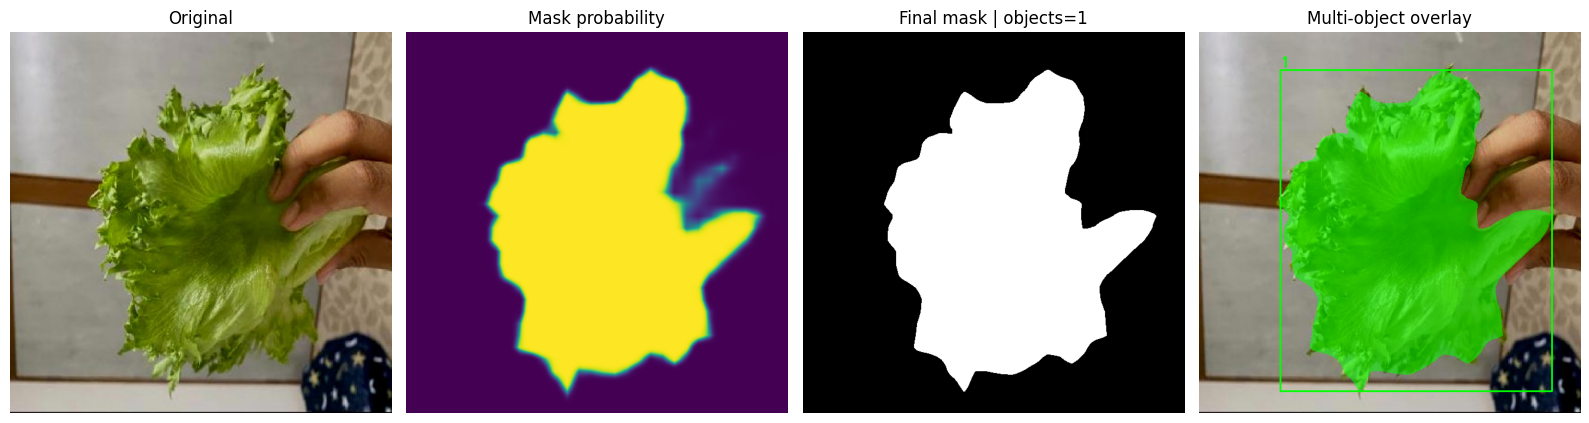

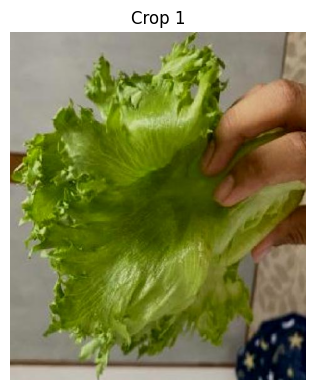

num objects: 1
{'object_id': 1, 'area': 142765, 'bbox_xyxy': [128, 57, 599, 611], 'num_polygons': 1, 'first_polygon_points': 25}


In [19]:
# =========================
# CELL 15 — VISUALIZE MODEL PREDICTION
# =========================

def visualize_prediction_from_path(image_path: str, threshold: float = SEG_MASK_THRESHOLD):
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)

    prob, mask, components = predict_mask_tta(
        seg_model,
        image,
        img_sizes=[IMG_SIZE],
        flips=[False, True],
        threshold=threshold,
        postprocess=True,
    )

    overlay = colorize_components_overlay(image_np, components)
    crops = []

    plt.figure(figsize=(16, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(image_np)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(prob, cmap="viridis")
    plt.title("Mask probability")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Final mask | objects={len(components)}")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(overlay)
    plt.title("Multi-object overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    if len(components) > 0:
        plt.figure(figsize=(4 * min(len(components), 5), 4))
        for idx, comp in enumerate(components[:5]):
            crop, crop_mask = crop_from_mask(image, comp["mask"])
            crops.append(crop)

            plt.subplot(1, min(len(components), 5), idx + 1)
            plt.imshow(crop)
            plt.title(f"Crop {idx+1}")
            plt.axis("off")
        plt.tight_layout()
        plt.show()

    print("num objects:", len(components))
    for idx, comp in enumerate(components):
        polys = polygon_from_mask(comp["mask"])
        print({
            "object_id": idx + 1,
            "area": comp["area"],
            "bbox_xyxy": mask_to_bbox(comp["mask"]),
            "num_polygons": len(polys),
            "first_polygon_points": len(polys[0]) if polys else 0,
        })

    return {
        "image": image,
        "prob": prob,
        "mask": mask,
        "components": components,
        "crops": crops,
    }


sample_item = random.choice(val_pairs)
pred_debug = visualize_prediction_from_path(sample_item["image_path"])

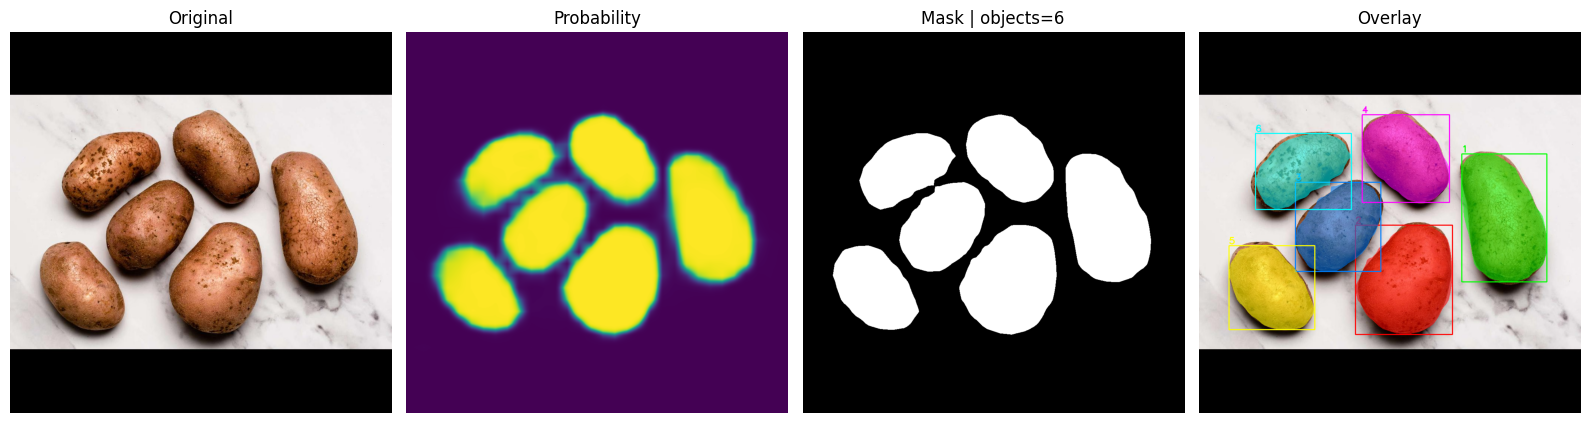

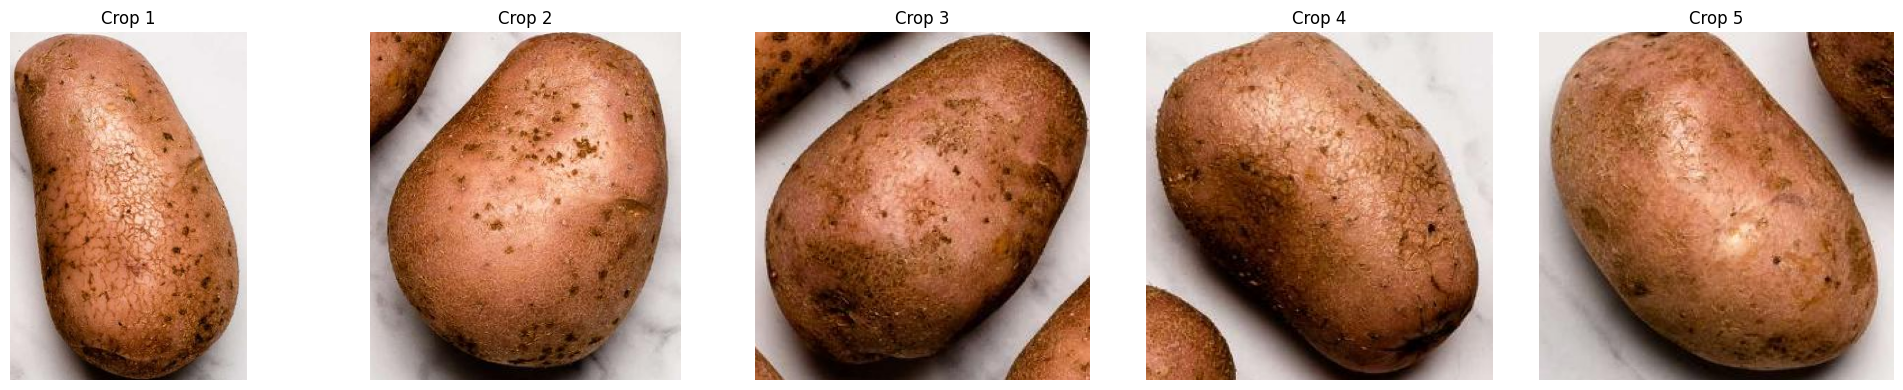

In [21]:
# =========================
# CELL 16 — TEST WITH INTERNET / LOCAL IMAGE
# =========================

import requests
from io import BytesIO

def load_image_from_url(url: str) -> Image.Image:
    r = requests.get(url, timeout=20)
    r.raise_for_status()
    return Image.open(BytesIO(r.content)).convert("RGB")


def run_segmentation_on_image(image: Image.Image, threshold: float = SEG_MASK_THRESHOLD):
    image = image.convert("RGB")
    image_np = np.array(image)

    prob, mask, components = predict_mask_tta(
        seg_model,
        image,
        img_sizes=[IMG_SIZE],
        flips=[False, True],
        threshold=threshold,
        postprocess=True,
    )

    overlay = colorize_components_overlay(image_np, components)

    objects = []
    for idx, comp in enumerate(components):
        crop, crop_mask = crop_from_mask(image, comp["mask"])
        polygons = polygon_from_mask(comp["mask"])

        objects.append({
            "object_id": idx + 1,
            "mask": comp["mask"],
            "area": comp["area"],
            "bbox_xyxy": mask_to_bbox(comp["mask"]),
            "polygon_xy": polygons[0] if polygons else [],
            "polygons": polygons,
            "crop": crop,
            "crop_mask": crop_mask,
        })

    plt.figure(figsize=(16, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(image_np)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(prob, cmap="viridis")
    plt.title("Probability")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask | objects={len(objects)}")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    if len(objects) > 0:
        plt.figure(figsize=(4 * min(len(objects), 5), 4))
        for idx, obj in enumerate(objects[:5]):
            plt.subplot(1, min(len(objects), 5), idx + 1)
            plt.imshow(obj["crop"])
            plt.title(f"Crop {idx+1}")
            plt.axis("off")
        plt.tight_layout()
        plt.show()

    return {
        "probability": prob,
        "mask": mask,
        "components": components,
        "objects": objects,
        # Backward compatible single-object fields.
        "bbox_xyxy": objects[0]["bbox_xyxy"] if objects else None,
        "polygons": objects[0]["polygons"] if objects else [],
        "crop": objects[0]["crop"] if objects else None,
    }


# Example:
IMAGE_URL = "https://source.roboflow.com/T1PNrECzJOYyz7BbXf5rjNeFrOc2/0J42xxgyS7Qk1ph69zqW/original.jpg"
test_img = load_image_from_url(IMAGE_URL)
seg_out = run_segmentation_on_image(test_img)

# Local:
# LOCAL_IMAGE_PATH = "/kaggle/input/your-test-image/lettuce.jpg"
# test_img = Image.open(LOCAL_IMAGE_PATH).convert("RGB")
# seg_out = run_segmentation_on_image(test_img)

## 17. Freshness classifier training

Bagian ini menambahkan training freshness beneran.

Model:
```text
EfficientNet-B0 via timm
output classes: fresh / medium / rotten
```

Dataset dibaca dari folder image di `/kaggle/input`, lalu label freshness diinfer dari nama folder/path:
- `fresh`, `healthy`, `good` → fresh
- `moderate`, `medium`, `moderatelyfresh`, `moderatelyhealthy`, `stale` → medium
- `notfresh`, `rotten`, `unhealthy`, `spoiled`, `bad` → rotten

Pastikan dataset freshness yang lu add ke Kaggle punya nama folder yang jelas.

In [22]:
# =========================
# CELL 17A — MULTI-DATASET FRESHNESS DISCOVERY FROM YOUR DATASETS
# =========================
# Supports:
# 1. YOLO datasets with data.yaml + labels/*.txt
# 2. Folder classification datasets like Tomato Quality Grading Dataset/Fresh, Rotten
#
# Output:
# fresh_pairs = [{"image_path": crop_or_image_path, "label": ..., "label_id": ..., "source_name": ...}]

from collections import Counter, defaultdict
from pathlib import Path
import yaml
import cv2
import numpy as np
from PIL import Image
import random
import shutil

FRESH_CLASS_NAMES = ["fresh", "medium", "rotten"]
FRESH_LABEL2ID = {name: idx for idx, name in enumerate(FRESH_CLASS_NAMES)}
FRESH_ID2LABEL = {idx: name for name, idx in FRESH_LABEL2ID.items()}

YOLO_FRESHNESS_ROOTS = [
    "/kaggle/input/datasets/athillazaidan/chili-freshness/Freshness chili segmentation.yolov8",
    "/kaggle/input/datasets/athillazaidan/kentang-freshness/Rotten and Healthy Potatoes.yolov8",
    "/kaggle/input/datasets/athillazaidan/lettuce-yolodataset",
]

FOLDER_FRESHNESS_ROOTS = [
    "/kaggle/input/datasets/sujaykapadnis/tomato-maturity-detection-and-quality-grading/Tomato Maturity Detection and Quality Grading Dataset",
]

FRESH_IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Save crops here. Training freshness on crops is better because inference also uses crops.
FRESH_CROP_DIR = WORK_DIR / "scresh_freshness_crops"
if FRESH_CROP_DIR.exists():
    shutil.rmtree(FRESH_CROP_DIR)
FRESH_CROP_DIR.mkdir(parents=True, exist_ok=True)

MAX_IMAGES_PER_CLASS_PER_SOURCE = 1200
CROP_PAD = 8


def normalize_name(s):
    return (
        str(s)
        .lower()
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "")
        .replace(".", "")
    )


def map_class_name_to_freshness(class_name):
    """
    Map dataset class name to fresh/medium/rotten.
    Order matters:
    - notfresh contains fresh
    - unhealthy contains healthy
    """
    s = normalize_name(class_name)

    rotten_keys = [
        "notfresh", "nothealthy", "rotten", "rotton", "unhealthy",
        "spoiled", "spoilt", "bad", "reject", "defect", "diseased",
        "decay", "damaged"
    ]

    medium_keys = [
        "moderatelyfresh", "moderatelyhealthy", "moderate", "medium",
        "semifresh", "semihealthy", "stale", "average",
        "slightlyrotten", "slightlyspoiled"
    ]

    fresh_keys = [
        "fresh", "healthy", "good", "accept", "normal"
    ]

    if any(k in s for k in rotten_keys):
        return "rotten"
    if any(k in s for k in medium_keys):
        return "medium"
    if any(k in s for k in fresh_keys):
        return "fresh"

    return None


def read_yolo_names(root):
    data_yaml = Path(root) / "data.yaml"
    if not data_yaml.exists():
        print("data.yaml not found:", data_yaml)
        return {}

    with open(data_yaml, "r") as f:
        data = yaml.safe_load(f)

    names = data.get("names", {})

    if isinstance(names, list):
        return {i: str(name) for i, name in enumerate(names)}

    if isinstance(names, dict):
        return {int(k): str(v) for k, v in names.items()}

    return {}


def find_label_for_image(img_path, root):
    """
    Common YOLO structure:
    root/train/images/img.jpg
    root/train/labels/img.txt

    or:
    root/images/train/img.jpg
    root/labels/train/img.txt
    """
    img_path = Path(img_path)
    root = Path(root)

    candidates = []

    parts = list(img_path.parts)

    if "images" in parts:
        idx = parts.index("images")
        label_parts = parts.copy()
        label_parts[idx] = "labels"
        candidates.append(Path(*label_parts).with_suffix(".txt"))

    # For structure train/images -> train/labels
    if img_path.parent.name == "images":
        candidates.append(img_path.parent.parent / "labels" / f"{img_path.stem}.txt")

    # Same folder fallback
    candidates.append(img_path.with_suffix(".txt"))

    for c in candidates:
        if c.exists():
            return c

    # Last resort search by stem
    found = list(root.rglob(img_path.stem + ".txt"))
    return found[0] if found else None


def yolo_obj_to_bbox(coords, W, H):
    """
    YOLO line coords after class id.
    Detection format:
      x_center y_center width height
    Segmentation format:
      x1 y1 x2 y2 ... xn yn
    all normalized.
    """
    vals = [float(x) for x in coords]

    if len(vals) == 4:
        xc, yc, bw, bh = vals
        x1 = int((xc - bw / 2) * W)
        y1 = int((yc - bh / 2) * H)
        x2 = int((xc + bw / 2) * W)
        y2 = int((yc + bh / 2) * H)
    else:
        if len(vals) % 2 != 0:
            return None

        pts = np.array(vals, dtype=np.float32).reshape(-1, 2)
        xs = pts[:, 0] * W
        ys = pts[:, 1] * H
        x1, y1, x2, y2 = int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())

    x1 = max(0, x1 - CROP_PAD)
    y1 = max(0, y1 - CROP_PAD)
    x2 = min(W - 1, x2 + CROP_PAD)
    y2 = min(H - 1, y2 + CROP_PAD)

    if x2 <= x1 or y2 <= y1:
        return None

    return x1, y1, x2, y2


def collect_yolo_freshness_crops():
    pairs = []

    for root in YOLO_FRESHNESS_ROOTS:
        root = Path(root)
        if not root.exists():
            print("YOLO root not found:", root)
            continue

        source_name = root.parent.name if root.name.endswith(".yolov8") else root.name
        names = read_yolo_names(root)

        print("\nYOLO source:", source_name)
        print("Root:", root)
        print("Class names:", names)

        class_map = {}
        for cid, cname in names.items():
            mapped = map_class_name_to_freshness(cname)
            class_map[cid] = mapped
            print(f"  class {cid}: {cname} -> {mapped}")

        image_paths = [
            p for p in root.rglob("*")
            if p.is_file() and p.suffix.lower() in FRESH_IMG_EXTS and "/images/" in str(p)
        ]

        print("Images found:", len(image_paths))

        crop_count = 0
        for img_path in image_paths:
            label_path = find_label_for_image(img_path, root)
            if label_path is None or not label_path.exists():
                continue

            try:
                img = Image.open(img_path).convert("RGB")
                W, H = img.size
            except Exception:
                continue

            lines = label_path.read_text(errors="ignore").strip().splitlines()
            for obj_idx, line in enumerate(lines):
                parts = line.strip().split()
                if len(parts) < 5:
                    continue

                try:
                    class_id = int(float(parts[0]))
                except Exception:
                    continue

                freshness_label = class_map.get(class_id)
                if freshness_label is None:
                    continue

                bbox = yolo_obj_to_bbox(parts[1:], W, H)
                if bbox is None:
                    continue

                x1, y1, x2, y2 = bbox
                crop = img.crop((x1, y1, x2 + 1, y2 + 1))

                # Skip tiny crops
                if crop.size[0] < 20 or crop.size[1] < 20:
                    continue

                out_dir = FRESH_CROP_DIR / source_name / freshness_label
                out_dir.mkdir(parents=True, exist_ok=True)

                out_path = out_dir / f"{img_path.stem}_obj{obj_idx}_{crop_count}.jpg"
                crop.save(out_path, quality=95)

                pairs.append({
                    "image_path": str(out_path),
                    "label": freshness_label,
                    "label_id": FRESH_LABEL2ID[freshness_label],
                    "source_name": source_name,
                    "original_image_path": str(img_path),
                    "label_path": str(label_path),
                    "class_id": class_id,
                    "class_name": names.get(class_id, str(class_id)),
                })

                crop_count += 1

        print("Crops collected:", crop_count)

    return pairs


def infer_folder_freshness_from_parents(path):
    """
    For classification datasets where folder names are Fresh / Rotten.
    Use parent folders only, not filename, to avoid random hash issue.
    """
    p = Path(path)
    parent_names = [x.name for x in list(p.parents)[:8]]

    # Use closest folder first.
    for name in parent_names:
        mapped = map_class_name_to_freshness(name)
        if mapped is not None:
            return mapped

    return None


def collect_folder_freshness_images():
    pairs = []

    for root in FOLDER_FRESHNESS_ROOTS:
        root = Path(root)
        if not root.exists():
            print("Folder root not found:", root)
            continue

        source_name = root.parent.name
        print("\nFolder source:", source_name)
        print("Root:", root)

        count = 0
        for p in root.rglob("*"):
            if not p.is_file() or p.suffix.lower() not in FRESH_IMG_EXTS:
                continue

            # Skip masks/annotations by filename
            fname = p.name.lower()
            if any(k in fname for k in ["mask", "label", "annotation", "overlay", "seg"]):
                continue

            label = infer_folder_freshness_from_parents(p)
            if label is None:
                continue

            pairs.append({
                "image_path": str(p),
                "label": label,
                "label_id": FRESH_LABEL2ID[label],
                "source_name": source_name,
                "original_image_path": str(p),
                "class_name": label,
            })
            count += 1

        print("Images collected:", count)

    return pairs


def cap_pairs_per_source_class(pairs, max_per_class_per_source=MAX_IMAGES_PER_CLASS_PER_SOURCE):
    if max_per_class_per_source is None:
        return pairs

    buckets = defaultdict(list)
    for item in pairs:
        key = (item["source_name"], item["label"])
        buckets[key].append(item)

    final = []
    for key, items in buckets.items():
        random.shuffle(items)
        final.extend(items[:max_per_class_per_source])

    random.shuffle(final)
    return final


def print_freshness_summary(pairs, title="SUMMARY"):
    print(f"\n=== {title} ===")
    print("Freshness images/crops found:", len(pairs))

    counts = Counter(x["label"] for x in pairs)
    print("Class counts:", dict(counts))

    source_label_counter = defaultdict(lambda: Counter())
    for x in pairs:
        source_label_counter[x["source_name"]][x["label"]] += 1

    print("\nCounts by source:")
    for src, counter in sorted(source_label_counter.items()):
        print(f"- {src:<45} total={sum(counter.values()):<6} {dict(counter)}")

    print("\nExamples:")
    for x in pairs[:20]:
        print(f"{x['label']:<7} | {x['source_name']:<35} | {x['image_path']}")


fresh_pairs_raw = []
fresh_pairs_raw.extend(collect_yolo_freshness_crops())
fresh_pairs_raw.extend(collect_folder_freshness_images())

print_freshness_summary(fresh_pairs_raw, title="RAW DISCOVERY")

fresh_pairs = cap_pairs_per_source_class(fresh_pairs_raw)

print_freshness_summary(fresh_pairs, title="AFTER CAP")

assert len(fresh_pairs) > 0, "No freshness images found."

missing = [c for c in FRESH_CLASS_NAMES if sum(1 for x in fresh_pairs if x["label"] == c) == 0]
if missing:
    print("\nWARNING missing classes:", missing)
    print("Kalau medium kosong, classifier tetap bisa train fresh/rotten, tapi Grade C akan lebih bergantung ke probability logic.")


YOLO source: chili-freshness
Root: /kaggle/input/datasets/athillazaidan/chili-freshness/Freshness chili segmentation.yolov8
Class names: {0: 'Fresh', 1: 'Moderately Fresh', 2: 'NotFresh'}
  class 0: Fresh -> fresh
  class 1: Moderately Fresh -> medium
  class 2: NotFresh -> rotten
Images found: 50
Crops collected: 70

YOLO source: kentang-freshness
Root: /kaggle/input/datasets/athillazaidan/kentang-freshness/Rotten and Healthy Potatoes.yolov8
Class names: {0: 'good potatoe', 1: 'rotten'}
  class 0: good potatoe -> fresh
  class 1: rotten -> rotten
Images found: 300
Crops collected: 306

YOLO source: lettuce-yolodataset
Root: /kaggle/input/datasets/athillazaidan/lettuce-yolodataset
Class names: {0: 'lettuce-healthy', 1: 'lettuce-moderately-healthy', 2: 'lettuce-unhealthy'}
  class 0: lettuce-healthy -> fresh
  class 1: lettuce-moderately-healthy -> medium
  class 2: lettuce-unhealthy -> rotten
Images found: 1886
Crops collected: 6466

Folder source: tomato-maturity-detection-and-qualit

In [23]:
# =========================
# CELL 17B — FRESHNESS DATASET + DATALOADER
# =========================

FRESH_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
FRESH_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def preprocess_freshness_image(image: Image.Image, img_size: int = FRESH_IMG_SIZE, train: bool = False):
    image = image.convert("RGB")

    if train:
        # Simple augmentations without torchvision.
        if random.random() < 0.5:
            image = image.transpose(Image.FLIP_LEFT_RIGHT)

        # Random brightness/contrast via PIL-free numpy operation.
        arr = np.asarray(image).astype(np.float32)
        if random.random() < 0.5:
            brightness = random.uniform(0.85, 1.15)
            contrast = random.uniform(0.85, 1.15)
            mean = arr.mean(axis=(0, 1), keepdims=True)
            arr = (arr - mean) * contrast + mean
            arr = arr * brightness
            arr = np.clip(arr, 0, 255).astype(np.uint8)
            image = Image.fromarray(arr)

    image = image.resize((img_size, img_size), resample=Image.BICUBIC)
    arr = np.asarray(image).astype(np.float32) / 255.0
    tensor = torch.from_numpy(arr).permute(2, 0, 1)
    tensor = (tensor - FRESH_MEAN) / FRESH_STD
    return tensor


class FreshnessDataset(Dataset):
    def __init__(self, pairs, train=False):
        self.pairs = pairs
        self.train = train

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        item = self.pairs[idx]
        image = Image.open(item["image_path"]).convert("RGB")
        x = preprocess_freshness_image(image, FRESH_IMG_SIZE, train=self.train)
        y = torch.tensor(item["label_id"], dtype=torch.long)
        return {
            "pixel_values": x,
            "label": y,
            "image_path": item["image_path"],
        }


# Stratified split if every class has at least 2 samples.
labels_for_split = [x["label_id"] for x in fresh_pairs]
class_counts = {i: labels_for_split.count(i) for i in range(len(FRESH_CLASS_NAMES))}
can_stratify = all(v >= 2 for v in class_counts.values())

fresh_train_pairs, fresh_val_pairs = train_test_split(
    fresh_pairs,
    test_size=0.2,
    random_state=SEED,
    shuffle=True,
    stratify=labels_for_split if can_stratify else None,
)

fresh_train_ds = FreshnessDataset(fresh_train_pairs, train=True)
fresh_val_ds = FreshnessDataset(fresh_val_pairs, train=False)

fresh_train_loader = DataLoader(
    fresh_train_ds,
    batch_size=FRESH_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

fresh_val_loader = DataLoader(
    fresh_val_ds,
    batch_size=FRESH_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print("fresh train:", len(fresh_train_ds), "fresh val:", len(fresh_val_ds))
b = next(iter(fresh_train_loader))
print("batch image:", b["pixel_values"].shape, "batch label:", b["label"].shape)

fresh train: 4274 fresh val: 1069
batch image: torch.Size([16, 3, 224, 224]) batch label: torch.Size([16])


In [24]:
# =========================
# CELL 17C — TRAIN FRESHNESS EFFICIENTNET-B0
# =========================

import sys
import subprocess

try:
    import timm
except ImportError:
    print("timm not installed. Installing timm...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "timm"])
    import timm

def build_freshness_model(pretrained=True):
    try:
        model = timm.create_model(
            FRESH_MODEL_NAME,
            pretrained=pretrained,
            num_classes=len(FRESH_CLASS_NAMES),
        )
    except Exception as e:
        print("Failed to load pretrained timm model. Falling back to pretrained=False.")
        print("Error:", e)
        model = timm.create_model(
            FRESH_MODEL_NAME,
            pretrained=False,
            num_classes=len(FRESH_CLASS_NAMES),
        )
    return model


fresh_model = build_freshness_model(pretrained=True).to(device)

# Class weights for imbalance.
label_ids = [x["label_id"] for x in fresh_train_pairs]
counts_np = np.array([max(1, label_ids.count(i)) for i in range(len(FRESH_CLASS_NAMES))], dtype=np.float32)
weights_np = counts_np.sum() / (len(FRESH_CLASS_NAMES) * counts_np)
weights_np = np.clip(weights_np, 0.5, 3.0)
class_weights = torch.tensor(weights_np, dtype=torch.float32, device=device)

print("class counts:", counts_np.tolist())
print("class weights:", weights_np.tolist())

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer_fresh = torch.optim.AdamW(
    fresh_model.parameters(),
    lr=FRESH_LR,
    weight_decay=FRESH_WEIGHT_DECAY,
)

fresh_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and device == "cuda")

def fresh_accuracy(logits, labels):
    preds = logits.argmax(dim=1)
    return (preds == labels).float().mean().item()

def run_fresh_epoch(model, loader, train=True):
    model.train() if train else model.eval()

    total_loss = 0.0
    total_acc = 0.0
    n_batches = 0

    pbar = tqdm(loader, desc="fresh train" if train else "fresh val")
    for batch in pbar:
        x = batch["pixel_values"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)

        if train:
            optimizer_fresh.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(train):
            with torch.cuda.amp.autocast(enabled=USE_AMP and device == "cuda"):
                logits = model(x)
                loss = criterion(logits, y)

            if train:
                fresh_scaler.scale(loss).backward()
                fresh_scaler.step(optimizer_fresh)
                fresh_scaler.update()

        acc = fresh_accuracy(logits.detach(), y.detach())
        total_loss += float(loss.item())
        total_acc += acc
        n_batches += 1

        pbar.set_postfix({
            "loss": total_loss / n_batches,
            "acc": total_acc / n_batches,
        })

    return {
        "loss": total_loss / max(1, n_batches),
        "acc": total_acc / max(1, n_batches),
    }


best_fresh_val_acc = -1.0
fresh_history = []

if TRAIN_FRESHNESS:
    for epoch in range(1, FRESH_EPOCHS + 1):
        print(f"\nFreshness Epoch {epoch}/{FRESH_EPOCHS}")

        train_m = run_fresh_epoch(fresh_model, fresh_train_loader, train=True)
        val_m = run_fresh_epoch(fresh_model, fresh_val_loader, train=False)

        row = {"epoch": epoch, "train": train_m, "val": val_m}
        fresh_history.append(row)

        print("fresh train:", train_m)
        print("fresh val  :", val_m)

        if val_m["acc"] > best_fresh_val_acc:
            best_fresh_val_acc = val_m["acc"]
            ckpt = {
                "model_name": FRESH_MODEL_NAME,
                "model_state_dict": fresh_model.state_dict(),
                "class_names": FRESH_CLASS_NAMES,
                "label2id": FRESH_LABEL2ID,
                "id2label": FRESH_ID2LABEL,
                "img_size": FRESH_IMG_SIZE,
                "best_val_acc": best_fresh_val_acc,
                "epoch": epoch,
                "history": fresh_history,
            }
            torch.save(ckpt, FRESH_MODEL_SAVE_PATH)
            print("Saved best freshness model:", FRESH_MODEL_SAVE_PATH)

    print("Best freshness val acc:", best_fresh_val_acc)
else:
    print("TRAIN_FRESHNESS=False. Skipping freshness training.")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

class counts: [2074.0, 394.0, 1806.0]
class weights: [0.6869173645973206, 3.0, 0.7888519763946533]

Freshness Epoch 1/8


/tmp/ipykernel_58/1724233403.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  fresh_scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP and device == "cuda")


fresh train:   0%|          | 0/268 [00:00<?, ?it/s]

/tmp/ipykernel_58/1724233403.py:74: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP and device == "cuda"):


...

fresh val:   0%|          | 0/67 [00:00<?, ?it/s]

fresh train: {'loss': 0.09127533380456383, 'acc': 0.9696828358208955}
fresh val  : {'loss': 0.24292602956962012, 'acc': 0.9466130893621871}
Saved best freshness model: /kaggle/working/scresh_freshness_efficientnet_b0_best.pt

Freshness Epoch 8/8


fresh train:   0%|          | 0/268 [00:00<?, ?it/s]

fresh val:   0%|          | 0/67 [00:00<?, ?it/s]

fresh train: {'loss': 0.06689447926903845, 'acc': 0.9773787313432836}
fresh val  : {'loss': 0.32396403864669054, 'acc': 0.9382175669741275}
Best freshness val acc: 0.9466130893621871


Loaded freshness: /kaggle/working/scresh_freshness_efficientnet_b0_best.pt
Best val acc: 0.9466130893621871


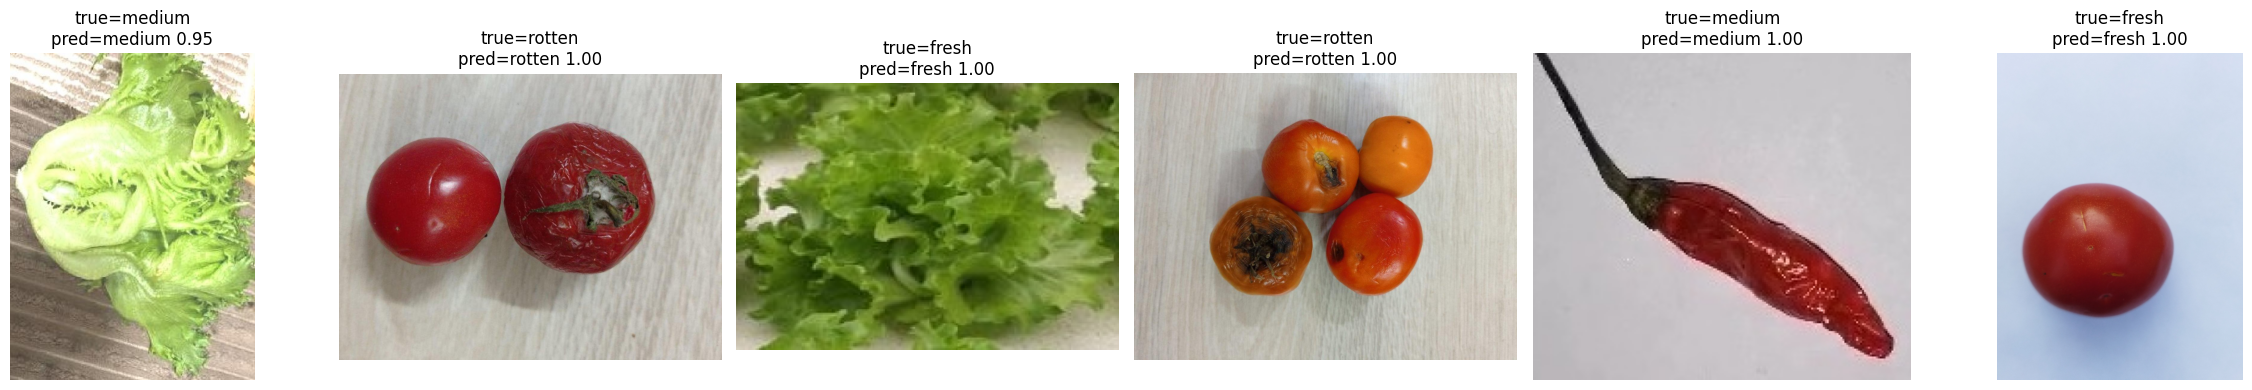

In [25]:
# =========================
# CELL 17D — LOAD + TEST FRESHNESS MODEL
# =========================

def load_freshness_model(path=FRESH_MODEL_SAVE_PATH):
    import timm

    ckpt = torch.load(path, map_location=device)
    model = timm.create_model(
        ckpt.get("model_name", FRESH_MODEL_NAME),
        pretrained=False,
        num_classes=len(ckpt["class_names"]),
    )
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device)
    model.eval()
    return model, ckpt


if FRESH_MODEL_SAVE_PATH.exists():
    fresh_model, fresh_ckpt = load_freshness_model(FRESH_MODEL_SAVE_PATH)
    FRESH_CLASS_NAMES = fresh_ckpt["class_names"]
    FRESH_LABEL2ID = fresh_ckpt["label2id"]
    FRESH_ID2LABEL = {int(k): v for k, v in fresh_ckpt["id2label"].items()} if isinstance(next(iter(fresh_ckpt["id2label"].keys())), str) else fresh_ckpt["id2label"]

    print("Loaded freshness:", FRESH_MODEL_SAVE_PATH)
    print("Best val acc:", fresh_ckpt.get("best_val_acc"))
else:
    print("No trained freshness model found yet.")


@torch.no_grad()
def predict_freshness_probs(crop: Image.Image):
    fresh_model.eval()
    x = preprocess_freshness_image(crop, FRESH_IMG_SIZE, train=False).unsqueeze(0).to(device)
    logits = fresh_model(x)
    probs = torch.softmax(logits, dim=1)[0].detach().cpu().numpy()

    prob_dict = {
        FRESH_CLASS_NAMES[i]: float(probs[i])
        for i in range(len(FRESH_CLASS_NAMES))
    }
    return prob_dict


def show_random_freshness_predictions(n=6):
    sample = random.sample(fresh_val_pairs, min(n, len(fresh_val_pairs)))

    plt.figure(figsize=(4 * len(sample), 4))
    for i, item in enumerate(sample):
        img = Image.open(item["image_path"]).convert("RGB")
        prob = predict_freshness_probs(img)
        pred = max(prob, key=prob.get)

        plt.subplot(1, len(sample), i + 1)
        plt.imshow(img)
        plt.title(f"true={item['label']}\npred={pred} {prob[pred]:.2f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


if FRESH_MODEL_SAVE_PATH.exists():
    show_random_freshness_predictions(n=6)

In [26]:
# =========================
# CELL 17E — FRESHNESS GRADING LOGIC
# =========================

def normalize_freshness_label(label):
    x = str(label).lower().replace("_", "").replace("-", "").replace(" ", "")

    if any(k in x for k in ["notfresh", "rotten", "unhealthy", "spoiled", "bad", "reject"]):
        return "rotten"
    if any(k in x for k in ["medium", "moderate", "moderatelyfresh", "moderatelyhealthy", "stale"]):
        return "medium"
    if any(k in x for k in ["fresh", "healthy", "good", "accept"]):
        return "fresh"

    return str(label)


def map_to_grade_smarter(prob):
    fresh_p = prob.get("fresh", 0)
    medium_p = prob.get("medium", 0)
    rotten_p = prob.get("rotten", 0)

    if rotten_p >= 0.70:
        return "D"
    if fresh_p >= 0.85:
        return "A"
    if fresh_p >= 0.45:
        return "B"
    if medium_p >= 0.45 and rotten_p < 0.30:
        return "B"
    if medium_p >= 0.50:
        return "C"
    if rotten_p >= 0.40:
        return "C"
    return "B"


SHELF_LIFE = {
    "lettuce": {"A": 5,  "B": 3, "C": 1, "D": 0},
    "chili":   {"A": 7,  "B": 4, "C": 2, "D": 0},
    "potato":  {"A": 14, "B": 7, "C": 3, "D": 0},
    "onion":   {"A": 14, "B": 7, "C": 3, "D": 0},
    "tomato":  {"A": 5,  "B": 3, "C": 1, "D": 0},
}


def get_recommendation(grade, shelf_life_days):
    if grade == "A":
        return f"Excellent freshness. Safe to store up to {shelf_life_days} days."
    if grade == "B":
        return f"Good freshness. Prioritize distribution within {shelf_life_days} days."
    if grade == "C":
        return f"At-risk batch. Distribute or process within {shelf_life_days} day."
    return "Reject or mark as waste. Do not distribute."


def predict_freshness(crop: Image.Image, commodity: str = "lettuce"):
    if crop is None:
        prob = {"fresh": 0.0, "medium": 1.0, "rotten": 0.0}
    elif "fresh_model" in globals() and fresh_model is not None:
        raw_prob = predict_freshness_probs(crop)

        # Normalize keys to fresh/medium/rotten.
        prob = {"fresh": 0.0, "medium": 0.0, "rotten": 0.0}
        for k, v in raw_prob.items():
            norm = normalize_freshness_label(k)
            if norm in prob:
                prob[norm] += float(v)
    else:
        # Fallback if model not trained.
        prob = {"fresh": 0.60, "medium": 0.35, "rotten": 0.05}

    grade = map_to_grade_smarter(prob)
    shelf = SHELF_LIFE.get(commodity, SHELF_LIFE["lettuce"])[grade]
    top_label = max(prob, key=prob.get)

    return {
        "commodity": commodity,
        "freshness_class": top_label,
        "confidence": float(prob[top_label]),
        "probabilities": {k: float(v) for k, v in prob.items()},
        "grade": grade,
        "shelf_life_days": shelf,
        "recommendation": get_recommendation(grade, shelf),
    }

In [27]:
# =========================
# CELL 18 — END-TO-END SCRESH INFERENCE MULTI-OBJECT
# =========================

def scresh_scan_image(
    image: Image.Image,
    commodity: str = "lettuce",
    threshold: float = SEG_MASK_THRESHOLD,
    image_index: int = 0,
):
    seg = run_segmentation_on_image(image, threshold=threshold)

    objects = []
    for obj in seg["objects"]:
        crop = obj["crop"]
        freshness = predict_freshness(crop, commodity=commodity)

        objects.append({
            "object_id": obj["object_id"],
            "class_name": "produce",
            "segmentation_area": int(obj["area"]),
            "bbox_xyxy": obj["bbox_xyxy"],
            "polygon_xy": obj["polygon_xy"],
            "freshness": freshness,
        })

    result = {
        "image_index": image_index,
        "objects": objects,
    }

    print(json.dumps(result, indent=2))
    return result


# Example:
# image = Image.open("/kaggle/input/your-test-image/lettuce.jpg").convert("RGB")
# result = scresh_scan_image(image, commodity="lettuce")

In [28]:
# =========================
# CELL 19 — BATCH AGGREGATION FOR 3–5 PHOTOS
# =========================

def aggregate_scresh_results(image_results: List[Dict], commodity: str = "lettuce"):
    probs = []
    rotten_max = 0.0
    object_count = 0

    for img_res in image_results:
        for obj in img_res.get("objects", []):
            object_count += 1
            p = obj["freshness"]["probabilities"]
            probs.append(p)
            rotten_max = max(rotten_max, p.get("rotten", 0.0))

    if not probs:
        avg_prob = {"fresh": 0.0, "medium": 1.0, "rotten": 0.0}
    else:
        avg_prob = {
            "fresh": float(np.mean([p.get("fresh", 0.0) for p in probs])),
            "medium": float(np.mean([p.get("medium", 0.0) for p in probs])),
            "rotten": float(np.mean([p.get("rotten", 0.0) for p in probs])),
        }

    if rotten_max >= 0.80:
        final_grade = "D"
    else:
        final_grade = map_to_grade_smarter(avg_prob)

    shelf = SHELF_LIFE.get(commodity, SHELF_LIFE["lettuce"])[final_grade]
    freshness_class = max(avg_prob, key=avg_prob.get)

    return {
        "commodity": commodity,
        "summary": {
            "freshness_class": freshness_class,
            "confidence": float(avg_prob[freshness_class]),
            "grade": final_grade,
            "shelf_life_days": shelf,
            "recommendation": get_recommendation(final_grade, shelf),
            "probabilities": avg_prob,
            "max_rotten_probability": float(rotten_max),
            "object_count": int(object_count),
        },
        "images": image_results,
    }


# Example:
# image_paths = ["/path/img1.jpg", "/path/img2.jpg", "/path/img3.jpg"]
# results = []
# for idx, p in enumerate(image_paths):
#     img = Image.open(p).convert("RGB")
#     results.append(scresh_scan_image(img, commodity="lettuce", image_index=idx))
# batch_result = aggregate_scresh_results(results, commodity="lettuce")
# print(json.dumps(batch_result, indent=2))

In [29]:
# =========================
# CELL 20 — EXPORT METADATA
# =========================

metadata = {
    "project": "Scresh",
    "segmentation_architecture": "DINOv3 frozen encoder + lightweight binary segmentation decoder",
    "segmentation_type": "binary semantic segmentation with connected-component multi-object extraction",
    "dino_model_id": DINO_MODEL_ID,
    "img_size": IMG_SIZE,
    "seg_model_path": str(SEG_MODEL_SAVE_PATH),
    "fresh_model_path": str(FRESH_MODEL_SAVE_PATH),
    "best_seg_val_iou": float(best_val_iou) if "best_val_iou" in globals() else None,
    "best_fresh_val_acc": float(best_fresh_val_acc) if "best_fresh_val_acc" in globals() else None,
    "multi_object": {
        "enabled": SEG_MULTI_OBJECT,
        "keep_largest_only": SEG_KEEP_LARGEST_ONLY,
        "min_component_area": SEG_MIN_COMPONENT_AREA,
        "max_objects": SEG_MAX_OBJECTS,
        "mask_threshold": SEG_MASK_THRESHOLD,
    },
    "label_filter": {
        "drop_boxy_seg_labels": DROP_BOXY_SEG_LABELS,
        "min_seg_polygon_points": MIN_SEG_POLYGON_POINTS,
        "min_mask_area_ratio": MIN_MASK_AREA_RATIO,
        "max_mask_area_ratio": MAX_MASK_AREA_RATIO,
    },
    "sources": [
        {k: v for k, v in src.items() if k in ["name", "path", "enabled"]}
        for src in SEG_SOURCES
    ],
    "freshness": {
        "model_name": FRESH_MODEL_NAME,
        "class_names": FRESH_CLASS_NAMES,
        "img_size": FRESH_IMG_SIZE,
        "freshness_classes": ["fresh", "medium", "rotten"],
        "grades": ["A", "B", "C", "D"],
        "shelf_life": SHELF_LIFE,
    },
}

with open(SEG_METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

with open(FRESH_METADATA_PATH, "w") as f:
    json.dump(metadata["freshness"], f, indent=2)

print("Saved segmentation metadata:", SEG_METADATA_PATH)
print("Saved freshness metadata:", FRESH_METADATA_PATH)
print(json.dumps(metadata, indent=2))

Saved segmentation metadata: /kaggle/working/scresh_dinov3_frozen_decoder_metadata.json
Saved freshness metadata: /kaggle/working/scresh_freshness_metadata.json
{
  "project": "Scresh",
  "segmentation_architecture": "DINOv3 frozen encoder + lightweight binary segmentation decoder",
  "segmentation_type": "binary semantic segmentation with connected-component multi-object extraction",
  "dino_model_id": "facebook/dinov3-vits16-pretrain-lvd1689m",
  "img_size": 512,
  "seg_model_path": "/kaggle/working/scresh_dinov3_frozen_decoder_best.pt",
  "fresh_model_path": "/kaggle/working/scresh_freshness_efficientnet_b0_best.pt",
  "best_seg_val_iou": 0.8678847959265112,
  "best_fresh_val_acc": 0.9466130893621871,
  "multi_object": {
    "enabled": true,
    "keep_largest_only": false,
    "min_component_area": 250,
    "max_objects": 10,
    "mask_threshold": 0.5
  },
  "label_filter": {
    "drop_boxy_seg_labels": true,
    "min_seg_polygon_points": 6,
    "min_mask_area_ratio": 0.005,
    "ma

## Backend integration note

Untuk FastAPI service, load:
- `AutoModel.from_pretrained(dino_model_id, token=HF_TOKEN)`
- manual preprocessing function `preprocess_dino_image`
- class `DINOv3BinarySegmentation`
- checkpoint `scresh_dinov3_frozen_decoder_best.pt`
- freshness checkpoint `scresh_freshness_efficientnet_b0_best.pt`
- helper `run_segmentation_on_image`
- helper `predict_freshness`

Catatan multi-object:
- Model segmentation ini **binary semantic segmentation**, bukan instance segmentation murni.
- Banyak objek bisa keluar kalau objeknya **terpisah sebagai connected components**.
- Kalau objek saling menempel/overlap, dia cenderung dianggap satu blob.
- Untuk instance-level yang lebih kuat, gunakan Mask2Former/YOLO instance segmentation.

Response minimal:

```json
{
  "batch_id": "...",
  "commodity": "potato",
  "summary": {
    "freshness_class": "fresh",
    "confidence": 0.91,
    "grade": "A",
    "shelf_life_days": 14,
    "recommendation": "Excellent freshness. Safe to store up to 14 days.",
    "object_count": 3
  },
  "images": [
    {
      "image_index": 0,
      "objects": [
        {
          "object_id": 1,
          "class_name": "produce",
          "bbox_xyxy": [10, 20, 300, 280],
          "polygon_xy": [[...]],
          "freshness": {
            "commodity": "potato",
            "freshness_class": "fresh",
            "confidence": 0.92,
            "grade": "A"
          }
        }
      ]
    }
  ]
}
```